# 환경 준비

In [ ]:
# ── 기본 라이브러리 ──────────────────────────────
import os
from pathlib import Path  # 폴더/파일 경로를 편하게 다루는 도구
from datetime import datetime  

import numpy as np
import pandas as pd  # 표(데이터프레임) 처리의 핵심

In [ ]:
# ── 메모리(RAM) 여유 확인 ────────────────────────
# 대여이력이 수백만 행이라, 돌리기 전에 남은 메모리를 체크
import psutil
ram = psutil.virtual_memory()
print(f"전체 RAM: {ram.total / 1024**3:.1f} GB")
print(f"사용 중: {ram.used / 1024**3:.1f} GB")
print(f"여유: {ram.available / 1024**3:.1f} GB")

전체 RAM: 15.7 GB
사용 중: 12.6 GB
여유: 3.0 GB


# 고장데이터 전처리

1-1 흩어진 고장신고 파일 12개 한 번에 읽기

In [ ]:
import pandas as pd
from pathlib import Path
from io import StringIO

# 1-1) 흩어진 고장신고 파일 12개 한 번에 읽기
folder = Path(r"C:\Users\USER\Desktop\따릉이\고장신고내역")
files = [f for f in folder.iterdir() if f.suffix.lower() in [".xlsx", ".xls", ".csv"]]
dfs = []  # 읽은 표들을 담을 바구니

for f in files:
    # 파일마다 저장 형식(인코딩)이 제각각이라 여러 방법으로 시도
    print("\n========================")
    print("파일명:", f.name)

    try:
        if f.suffix.lower() in [".xlsx", ".xls"]:
            df = pd.read_excel(f)
        elif f.suffix.lower() == ".csv":
            try:
                df = pd.read_csv(f, encoding="cp949") # 한국 공공데이터는 cp949가 많음
            except:
                try:
                    df = pd.read_excel(f)  # ← xlsx인데 csv로 저장된 경우
                    print("※ xlsx 형식으로 읽음")
                except:
                    try:
                        df = pd.read_csv(f, encoding="utf-8-sig")
                    except:
                        df = pd.read_csv(f, encoding="euc-kr")

        print("shape:", df.shape)
        dfs.append(df)
        print("컬럼명:", df.columns.tolist())
        print(df.head(2))

    except Exception as e:
        print("읽기 실패:", e)


파일명: 서울시 공공자전거 고장신고 내역_2020.11~2021.01 (1).csv
shape: (6749, 3)
컬럼명: ['자전거번호', '등록일시', '고장구분']
       자전거번호             등록일시 고장구분
0  SPB-37924  2020-11-01 0:10  기타 
1  SPB-43077  2020-11-01 0:24   안장

파일명: 서울시 공공자전거 고장신고 내역_21.02-21.06.csv
shape: (53843, 3)
컬럼명: ['자전거번호', '등록일시', '고장구분']
       자전거번호      등록일시  고장구분
0  SPB-51735  2021-2-1  타이어 
1  SPB-52819  2021-2-1   기타 

파일명: 서울시 공공자전거 고장신고 내역_21.7-21.12.csv
shape: (95689, 3)
컬럼명: ['자전거번호', '등록일시', '고장구분']
       자전거번호        등록일시 고장구분
0  SPB-48144  2021-07-01  기타 
1  SPB-53580  2021-07-01  기타 

파일명: 서울시 공공자전거 고장신고 내역_22.01-06.csv
shape: (74924, 3)
컬럼명: ['자전거번호', '등록일시', '고장구분']
       자전거번호             등록일시 고장구분
0  SPB-36049  2022-01-01 0:45  기타 
1  SPB-34190  2022-01-01 1:01  기타 

파일명: 서울시 공공자전거 고장신고 내역_22.07-12.csv
※ xlsx 형식으로 읽음
shape: (105550, 3)
컬럼명: ['자전거번호', '등록일시', '고장구분']
       자전거번호                등록일시 고장구분
0  SPB-30229 2022-07-01 00:44:33   페달
1  SPB-40134 2022-07-01 00:57:59   페달

파일명: 서울시 공공자전거 고장신고 내역_23.1-6.csv
sha

In [4]:
for f in folder.iterdir():
    print(f.name)

서울시 공공자전거 고장신고 내역_2020.11~2021.01 (1).csv
서울시 공공자전거 고장신고 내역_21.02-21.06.csv
서울시 공공자전거 고장신고 내역_21.7-21.12.csv
서울시 공공자전거 고장신고 내역_22.01-06.csv
서울시 공공자전거 고장신고 내역_22.07-12.csv
서울시 공공자전거 고장신고 내역_23.1-6.csv
서울시 공공자전거 고장신고 내역_23.11-12.csv
서울시 공공자전거 고장신고 내역_23.7-10.csv
서울시 공공자전거 고장신고 내역_2401-2406.csv
서울시 공공자전거 고장신고 내역_2407-2412.csv
서울시 공공자전거 고장신고 내역_2501-2506 (1).csv
서울시 공공자전거 고장신고 내역_2507-2512 (3).csv


In [5]:
df = pd.read_excel("서울시 공공자전거 고장신고 내역_22.07-12.csv")

In [6]:
dfs.append(df)
len(dfs)

13

1-2 컬럼명 통일 후 하나로 합치기 


컬럼 이름을 맞추고(rename), 세로로 붙이고(concat), 뒤죽박죽인 날짜 문자열을 진짜 날짜 타입으로 바꿉니다. 

In [ ]:
# 어떤 파일은 '고장구분', 어떤 파일은 '구분' → 이름 통일
for i in range(len(dfs)):
    dfs[i] = dfs[i].rename(columns={"구분": "고장구분"})

In [ ]:
# 12개 표를 세로로 이어붙이기
merged = pd.concat(dfs, ignore_index=True)

# 공백 제거
merged["등록일시"] = merged["등록일시"].astype(str).str.strip()

# 형식이 섞여 있으니 mixed 사용
merged["등록일시"] = pd.to_datetime(
    merged["등록일시"],
    format="mixed",
    errors="coerce"
)
import pandas as pd
from datetime import date

# 등록일시를 datetime으로 변환
broken_date = pd.to_datetime(merged["등록일시"], format="mixed", errors="coerce")

# 날짜만 따로 추출
merged["date"] = merged["등록일시"].dt.date

# 변환 실패 행 확인
print(merged["등록일시"].isnull().sum())

0


 1-3) 분석용 표 BR 만들기 (2021년 이후만)

최종적으로 필요한 세 가지(bike 자전거번호, date 날짜, type 고장유형)만 뽑아 깔끔한 표 BR을 만듭니다. 자전거번호는 SPB- 접두어를 떼고 숫자만 남김

In [ ]:
types = ["체인","기타","단말기","안장","페달","타이어","파손","잠금장치 불량"]
mask = merged["date"] >= pd.Timestamp("2021-01-01")   # 2021년부터만 사용

In [ ]:
# 등록일시를 datetime으로 변환
merged["date"] = pd.to_datetime(merged["등록일시"], format="mixed", errors="coerce")

# 2021-01-01 이후만 선택
mask = merged["date"] >= pd.Timestamp("2021-01-01")

BR = pd.DataFrame({
    "bike": pd.to_numeric(
        merged.loc[mask, "자전거번호"].astype(str).str.replace("SPB-", "", regex=False),
        errors="coerce"
    ),
    "date": merged.loc[mask, "date"].dt.date,
    "type": pd.Categorical(
        merged.loc[mask, "고장구분"].astype(str).str.strip(),
        categories=types
    )
}).reset_index(drop=True)

In [ ]:
print(BR.head())
print(BR.dtypes)
print(BR.isna().sum())

    bike        date type
0  41936  2021-01-01   기타
1  42181  2021-01-01  타이어
2  36237  2021-01-01   기타
3  33399  2021-01-01   체인
4  36328  2021-01-01   기타
bike       int64
date      object
type    category
dtype: object
bike    0
date    0
type    0
dtype: int64


In [ ]:
# 확인
print(BR['type'].value_counts(dropna=False))
# NaN이 많으면 공백 때문에 Categorical 매칭 실패한 거예요 

type
기타         256896
체인         175486
타이어        167335
안장         152475
페달          91136
단말기         41274
파손              0
잠금장치 불량         0
Name: count, dtype: int64


 1-4) 집계 (날짜별·자전거별 고장 건수)

In [ ]:
# # 날짜별 하루 총 고장 건수
daily_failure = BR.groupby('date').size().reset_index(name='failure_count')
daily_failure = daily_failure.sort_values('date').reset_index(drop=True)

print(daily_failure)

            date  failure_count
0     2021-01-01             35
1     2021-01-02             42
2     2021-01-03             46
3     2021-01-04             55
4     2021-01-05             69
...          ...            ...
1816  2025-12-27            130
1817  2025-12-28            105
1818  2025-12-29            176
1819  2025-12-30            217
1820  2025-12-31            308

[1821 rows x 2 columns]


In [ ]:
# 자전거 한 대당 고장 횟수 (많이 고장 나는 자전거 파악)
friq = BR["bike"].value_counts().reset_index()
friq.columns = ["bike", "n"]

print(friq.head(10))

    bike    n
0  53008  122
1  53847  120
2  36306  120
3  53300  107
4  33489  106
5  50393  101
6  32024   99
7  50747   94
8  51149   93
9  37080   89


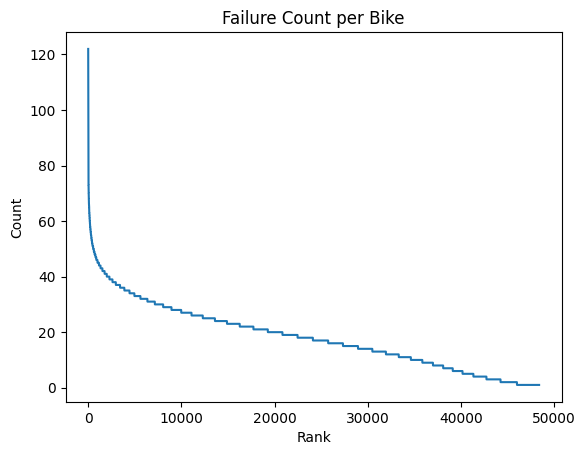

In [ ]:
import matplotlib.pyplot as plt

plt.plot(friq["n"].values)
plt.title("Failure Count per Bike")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.show()

In [ ]:
print("접수된 자전거 수:", BR["bike"].astype(str).nunique())
print("전체 신고 건수:", len(BR))

접수된 자전거 수: 48379
전체 신고 건수: 884602


=== 기본 현황 ===
총 고장 건수: 884,602건
고장 자전거 수: 48,379대
날짜 범위: 2021-01-01일 ~ 2025-12-31일
(기준일 2015-09-18 기준 경과일)

=== 고장 유형 분포 ===
type
기타         256896
체인         175486
타이어        167335
안장         152475
페달          91136
단말기         41274
파손              0
잠금장치 불량         0
Name: count, dtype: int64

비율:
type
기타         29.0%
체인         19.8%
타이어        18.9%
안장         17.2%
페달         10.3%
단말기         4.7%
파손          0.0%
잠금장치 불량     0.0%
Name: count, dtype: object

=== 자전거별 고장 건수 ===
count    48379.0
mean        18.3
std         11.9
min          1.0
25%          9.0
50%         17.0
75%         26.0
max        122.0
dtype: float64

고장 1회:  2,383대
고장 5회 이상:  41,322대
고장 10회 이상: 35,845대
최다 고장 자전거: 53008번 (122회)

=== 연도별 고장 건수 ===
year
2021    150940
2022    286024
2023    172913
2024    161846
2025    112879
dtype: int64

=== 월별 고장 건수 ===
month
1      29948
2      27070
3      45388
4      72534
5      85478
6      83529
7      93959
8      96464
9     113166
10    110225
11     7794

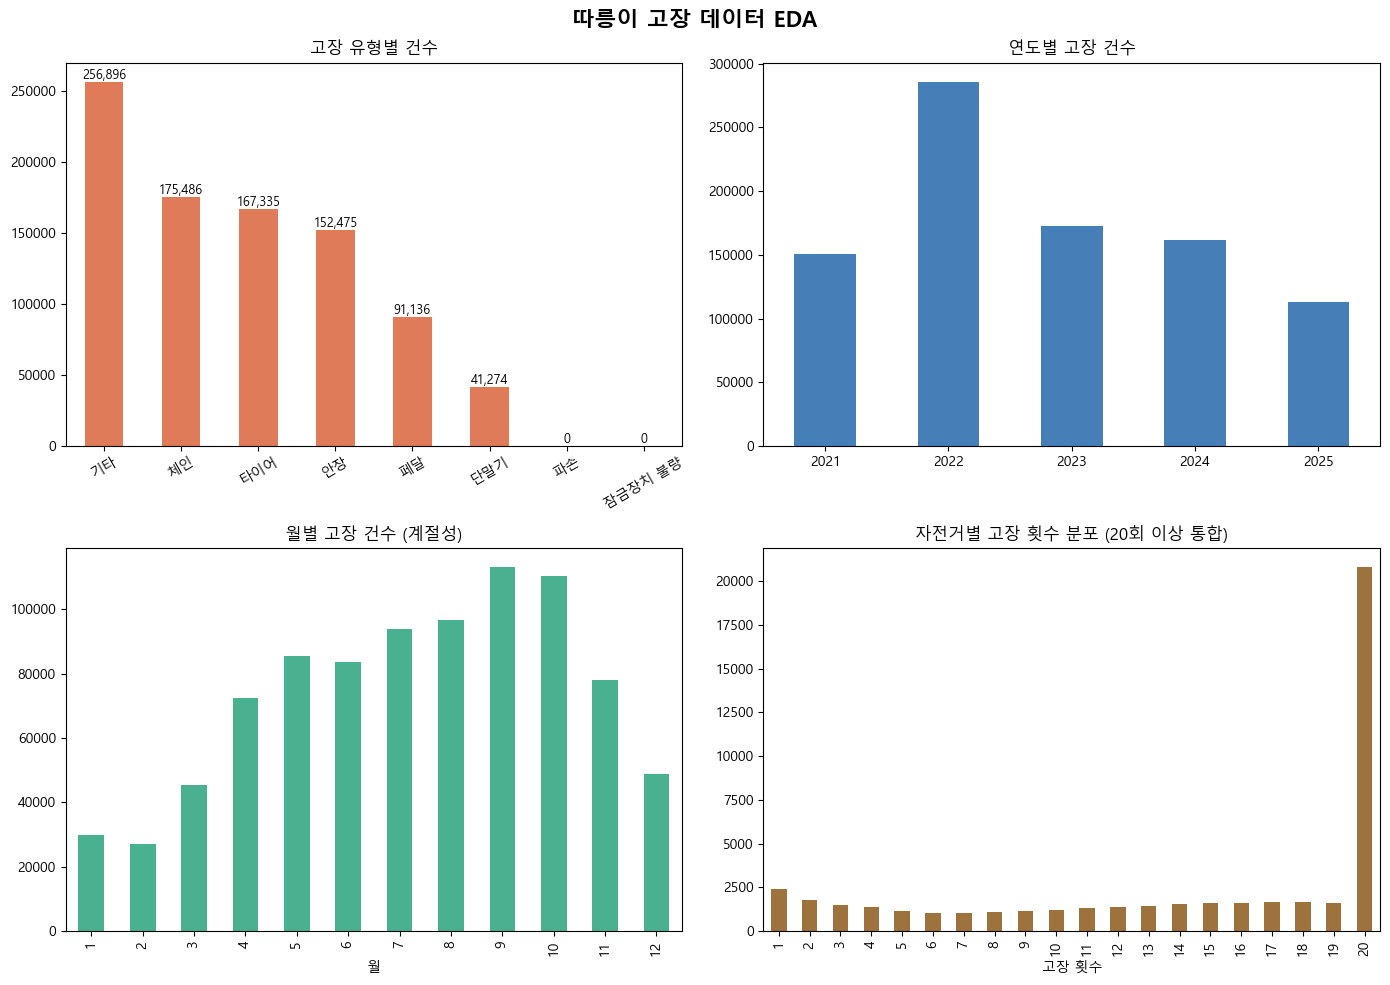

저장 완료: eda_고장데이터.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 1. 기본 현황 ────────────────────────────────────────────
print("=== 기본 현황 ===")
print(f"총 고장 건수: {len(BR):,}건")
print(f"고장 자전거 수: {BR['bike'].nunique():,}대")
print(f"날짜 범위: {BR['date'].min()}일 ~ {BR['date'].max()}일")
print(f"(기준일 2015-09-18 기준 경과일)")

# ── 2. 고장 유형 분포 ───────────────────────────────────────
print("\n=== 고장 유형 분포 ===")
type_cnt = BR['type'].value_counts()
print(type_cnt)
print(f"\n비율:")
print((type_cnt / len(BR) * 100).round(1).astype(str) + '%')

# ── 3. 자전거별 고장 건수 분포 ─────────────────────────────
bike_cnt = BR.groupby('bike').size()
print("\n=== 자전거별 고장 건수 ===")
print(bike_cnt.describe().round(1))
print(f"\n고장 1회:  {(bike_cnt==1).sum():,}대")
print(f"고장 5회 이상:  {(bike_cnt>=5).sum():,}대")
print(f"고장 10회 이상: {(bike_cnt>=10).sum():,}대")
print(f"최다 고장 자전거: {bike_cnt.idxmax()}번 ({bike_cnt.max()}회)")

# ── 4. 연도별 고장 추이 ─────────────────────────────────────
# date(경과일)를 실제 날짜로 복원
BR["date"] = pd.to_datetime(BR["date"], errors="coerce")
BR["year"] = BR["date"].dt.year
BR["month"] = BR["date"].dt.month


print("\n=== 연도별 고장 건수 ===")
print(BR.groupby('year').size())

# ── 5. 월별 고장 패턴 (계절성) ─────────────────────────────
print("\n=== 월별 고장 건수 ===")
print(BR.groupby('month').size())

# ── 6. 시각화 ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('따릉이 고장 데이터 EDA', fontsize=16, fontweight='bold')

# 고장 유형 분포
ax1 = axes[0, 0]
type_cnt.plot(kind='bar', ax=ax1, color='#D85A30', alpha=0.8)
ax1.set_title('고장 유형별 건수')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)

# 연도별 추이
ax2 = axes[0, 1]
BR.groupby('year').size().plot(kind='bar', ax=ax2, color='#185FA5', alpha=0.8)
ax2.set_title('연도별 고장 건수')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)

# 월별 패턴
ax3 = axes[1, 0]
BR.groupby('month').size().plot(kind='bar', ax=ax3, color='#1D9E75', alpha=0.8)
ax3.set_title('월별 고장 건수 (계절성)')
ax3.set_xlabel('월')
ax3.set_xticks(range(12))
ax3.set_xticklabels(range(1, 13))

# 자전거별 고장 횟수 분포
ax4 = axes[1, 1]
bike_cnt.clip(upper=20).value_counts().sort_index().plot(
    kind='bar', ax=ax4, color='#854F0B', alpha=0.8)
ax4.set_title('자전거별 고장 횟수 분포 (20회 이상 통합)')
ax4.set_xlabel('고장 횟수')

plt.tight_layout()
plt.savefig('eda_고장데이터.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: eda_고장데이터.png")

# 이용(대여이력) 데이터 전처리 — 5개년

In [2]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

 2-1) 대여이력 60개 파일 정제 후 저장

대여이력은 파일이 60개·수백만 행이라 한 번에 다 못 올려요. 그래서 "한 파일 읽기 → 컬럼 정리 → use 폴더에 저장"을 반복하는 방식으로 메모리를 아낍니다. set_num은 자전거번호를 숫자로 바꾸는 도우미 함수

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

def set_num(txt):  # 'SPB-64783' → 64783 로 변환하는 헬퍼
    try:
        return int(str(txt).replace("SPB-", "").strip().strip("'"))
    except:
        return np.nan

# 기준 폴더
base = Path(r"C:\Users\USER\Desktop\따릉이")

# 원본 csv 파일 목록
files = sorted((base / "대여이력").glob("*.csv"))

# 저장 폴더 생성
use_dir = base / "use"
use_dir.mkdir(exist_ok=True)  # 정제본 저장 폴더

print("파일 개수:", len(files))
print("저장 위치:", use_dir)

# 파일 확인
for i, f in enumerate(files):
    print(i, ":", f.name)

# 전처리 작업
for i, f in enumerate(files):
    x = pd.read_csv(f, encoding="cp949", low_memory=False)

    # 파일마다 다른 컬럼명을 표준 이름으로 매핑
    col_map = {}
    for col in x.columns:
        if "자전거번호" in col:
            col_map[col] = "자전거번호"
        elif "대여일시" in col:
            col_map[col] = "대여일시"
        elif "반납일시" in col:
            col_map[col] = "반납일시"
        elif "이용시간" in col:
            col_map[col] = "이용시간(분)"
        elif "이용거리" in col:
            col_map[col] = "이용거리(M)"

    x = x.rename(columns=col_map)
    x = x[["자전거번호", "대여일시", "반납일시", "이용시간(분)", "이용거리(M)"]].copy()

    x["자전거번호"] = x["자전거번호"].map(set_num)
    x["대여일시_dt"] = pd.to_datetime(x["대여일시"], errors="coerce")
    x["대여일수"] = (x["대여일시_dt"] - pd.Timestamp("2015-09-18")).dt.days

    # 한 파일씩 정제해서 저장 → 메모리 폭발 방지
    x.to_csv(use_dir / f"_Bike-Use{i}.csv", index=False, encoding="utf-8-sig")

    print("저장 완료:", f.name)

# 저장 확인
saved = sorted(use_dir.glob("_Bike-Use*.csv"))
print("저장된 파일 수:", len(saved))

파일 개수: 60
저장 위치: C:\Users\USER\Desktop\따릉이\use
0 : 공공자전거 대여이력 정보_2021.01 (2).csv
1 : 공공자전거 대여이력 정보_2021.02.csv
2 : 공공자전거 대여이력 정보_2021.03.csv
3 : 공공자전거 대여이력 정보_2021.04.csv
4 : 공공자전거 대여이력 정보_2021.05.csv
5 : 공공자전거 대여이력 정보_2021.06.csv
6 : 공공자전거 대여이력 정보_2107.csv
7 : 공공자전거 대여이력 정보_2108.csv
8 : 공공자전거 대여이력 정보_2109.csv
9 : 공공자전거 대여이력 정보_2110.csv
10 : 공공자전거 대여이력 정보_2111.csv
11 : 공공자전거 대여이력 정보_2112.csv
12 : 서울특별시 공공자전거 대여이력 정보_22.01.csv
13 : 서울특별시 공공자전거 대여이력 정보_22.02.csv
14 : 서울특별시 공공자전거 대여이력 정보_22.03.csv
15 : 서울특별시 공공자전거 대여이력 정보_22.04 (1).csv
16 : 서울특별시 공공자전거 대여이력 정보_22.05 (1).csv
17 : 서울특별시 공공자전거 대여이력 정보_22.06 (1).csv
18 : 서울특별시 공공자전거 대여이력 정보_2207 (1).csv
19 : 서울특별시 공공자전거 대여이력 정보_22081.csv
20 : 서울특별시 공공자전거 대여이력 정보_2209.csv
21 : 서울특별시 공공자전거 대여이력 정보_2210.csv
22 : 서울특별시 공공자전거 대여이력 정보_2211.csv
23 : 서울특별시 공공자전거 대여이력 정보_2212.csv
24 : 서울특별시 공공자전거 대여이력 정보_2301.csv
25 : 서울특별시 공공자전거 대여이력 정보_2302.csv
26 : 서울특별시 공공자전거 대여이력 정보_2303.csv
27 : 서울특별시 공공자전거 대여이력 정보_2304.csv
28 : 서울특별시 공공자전거 대여이력 정보_2305.csv
29 :

In [ ]:
print("date 결측 수:", x['대여일시'].isna().sum())
print(x[x['대여일시'].isna()].head())

date 결측 수: 0
Empty DataFrame
Columns: [자전거번호, 대여일시, 반납일시, 이용시간(분), 이용거리(M), 대여일시_dt, 대여일수]
Index: []


In [ ]:
#이용시간 max-1439분, 이용거리 max-81km->
print(x[['이용시간(분)', '이용거리(M)']].describe())

            이용시간(분)       이용거리(M)
count  1.965170e+06  1.965170e+06
mean   1.779140e+01  1.848490e+03
std    2.436106e+01  2.182216e+03
min    0.000000e+00  0.000000e+00
25%    5.000000e+00  7.169300e+02
50%    9.000000e+00  1.202140e+03
75%    1.900000e+01  2.120000e+03
max    1.439000e+03  8.181596e+04


2-2) 이상치 표시 & 하루 사용량 집계

In [ ]:
# 비정상 이용 표시: 3시간 초과 or 10km 초과
x['is_abnormal'] = ((x['이용시간(분)'] > 180) | (x['이용거리(M)'] > 10000)).astype(int)

In [ ]:
x

,자전거번호,대여일시,반납일시,이용시간(분),이용거리(M),대여일시_dt,대여일수,is_abnormal
0,64783,2025-12-01 00:00:59,2025-12-01 00:03:22,2,176.29,2025-12-01 00:00:59,3727,0
1,64275,2025-12-01 00:01:52,2025-12-01 00:03:45,1,270.00,2025-12-01 00:01:52,3727,0
2,37686,2025-12-01 00:01:29,2025-12-01 00:04:04,2,0.00,2025-12-01 00:01:29,3727,0
3,69829,2025-12-01 00:00:35,2025-12-01 00:04:19,3,633.73,2025-12-01 00:00:35,3727,0
4,59846,2025-12-01 00:00:06,2025-12-01 00:04:21,4,0.00,2025-12-01 00:00:06,3727,0
...,...,...,...,...,...,...,...,...
1965165,71112,2025-12-31 23:33:08,2026-01-01 01:37:26,124,2190.00,2025-12-31 23:33:08,3757,0
1965166,74398,2025-12-31 23:46:53,2026-01-01 01:43:22,116,3032.04,2025-12-31 23:46:53,3757,0
1965167,63917,2025-12-31 23:52:27,2026-01-01 01:44:17,111,18201.69,2025-12-31 23:52:27,3757,1
1965168,61297,2025-12-31 22:00:11,2026-01-01 01:46:28,226,8434.68,2025-12-31 22:00:11,3757,1


In [ ]:
# 정제본들을 다시 읽어 날짜별 대여 건수 합산
# 하루 사용량
daily_list = []

for i, f in enumerate(sorted(Path("use").glob("*.csv"))):
    df = pd.read_csv(f)
    df['대여일시_dt'] = pd.to_datetime(df['대여일시_dt'], errors='coerce')
    df['date'] = df['대여일시_dt'].dt.date
    
    daily = df.groupby('date').size().reset_index(name='usage')
    daily_list.append(daily)
    print(f"파일 {i} 완료")

# 전체 합치기
daily_usage = pd.concat(daily_list, ignore_index=True)

# 같은 날짜가 여러 파일에 걸쳐 있을 수 있으니 날짜별로 다시 합산
daily_usage = daily_usage.groupby('date')['usage'].sum().reset_index()
daily_usage = daily_usage.sort_values('date').reset_index(drop=True)

print(daily_usage)
daily_usage.to_csv("daily_usage.csv", index=False, encoding="utf-8-sig")

파일 0 완료
파일 1 완료
파일 2 완료
파일 3 완료
파일 4 완료
파일 5 완료
파일 6 완료
파일 7 완료
파일 8 완료
파일 9 완료
파일 10 완료
파일 11 완료
파일 12 완료
파일 13 완료
파일 14 완료
파일 15 완료
파일 16 완료
파일 17 완료
파일 18 완료
파일 19 완료
파일 20 완료
파일 21 완료
파일 22 완료
파일 23 완료
파일 24 완료
파일 25 완료
파일 26 완료
파일 27 완료
파일 28 완료
파일 29 완료
파일 30 완료
파일 31 완료
파일 32 완료
파일 33 완료
파일 34 완료
파일 35 완료
파일 36 완료
파일 37 완료
파일 38 완료
파일 39 완료
파일 40 완료
파일 41 완료
파일 42 완료
파일 43 완료
파일 44 완료
파일 45 완료
파일 46 완료
파일 47 완료
파일 48 완료
파일 49 완료
파일 50 완료
파일 51 완료
파일 52 완료
파일 53 완료
파일 54 완료
파일 55 완료
파일 56 완료
파일 57 완료
파일 58 완료
파일 59 완료
            date  usage
0     2021-01-01  22119
1     2021-01-02  23463
2     2021-01-03  21656
3     2021-01-04  32732
4     2021-01-05  28819
...          ...    ...
1821  2025-12-27  42381
1822  2025-12-28  40774
1823  2025-12-29  66652
1824  2025-12-30  71026
1825  2025-12-31  55570

[1826 rows x 2 columns]


In [ ]:
print(daily_usage.head())
print(daily_usage.shape)

         date  usage
0  2021-01-01  22119
1  2021-01-02  23463
2  2021-01-03  21656
3  2021-01-04  32732
4  2021-01-05  28819
(1826, 2)


# 날씨 데이터 전처리

In [ ]:
#한국 공공데이터 = cp949 많이 씀
weather = pd.read_csv(r"C:\Users\USER\Desktop\따릉이\기상청날씨데이터.csv", encoding="cp949")
weather=weather[['일시','평균기온(°C)','최저기온(°C)', '최저기온(°C)','일강수량(mm)','일 최심적설(cm)','합계 3시간 신적설(cm)']]
# 날짜 컬럼 datetime으로 변환
weather["날짜"] = pd.to_datetime(weather["일시"])

# 2021-01-01 이후 데이터만
weather = weather[weather["날짜"] >= "2021-01-01"]

In [ ]:
weather.columns

Index(['일시', '평균기온(°C)', '최저기온(°C)', '최저기온(°C)', '일강수량(mm)', '일 최심적설(cm)',
       '합계 3시간 신적설(cm)', '날짜'],
      dtype='object')

In [ ]:
weather.isnull().sum()

일시                   0
평균기온(°C)             0
최저기온(°C)             1
최저기온(°C)             1
일강수량(mm)          1051
일 최심적설(cm)        1695
합계 3시간 신적설(cm)    1749
날짜                   0
dtype: int64

In [ ]:
# 결측치 처리: 비/눈은 '안 왔다=0', 기온은 평균으로 채움
weather["일강수량(mm)"] = weather["일강수량(mm)"].fillna(0)
weather["일 최심적설(cm)"] = weather["일 최심적설(cm)"].fillna(0)
weather["합계 3시간 신적설(cm)"] = weather["합계 3시간 신적설(cm)"].fillna(0)
weather["최저기온(°C)"] = weather["최저기온(°C)"].fillna(weather["최저기온(°C)"].mean())

In [ ]:
weather.describe()

,평균기온(°C),최저기온(°C),최저기온(°C),일강수량(mm),일 최심적설(cm),합계 3시간 신적설(cm),날짜
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826
mean,14.037076,10.018904,10.018904,4.082366,0.198138,0.105257,2023-07-02 12:00:00
min,-14.900000,-18.600000,-18.600000,0.000000,0.000000,0.000000,2021-01-01 00:00:00
25%,5.100000,0.900000,0.900000,0.000000,0.000000,0.000000,2022-04-02 06:00:00
50%,15.100000,10.700000,10.700000,0.000000,0.000000,0.000000,2023-07-02 12:00:00
75%,23.400000,19.600000,19.600000,0.500000,0.000000,0.000000,2024-09-30 18:00:00
max,32.800000,29.300000,29.300000,176.200000,28.600000,23.400000,2025-12-31 00:00:00
std,10.704579,11.008414,11.008414,13.855970,1.226527,0.868988,NaN


# 명절/공휴일 변수

In [ ]:
!pip install holidays
import pandas as pd
import holidays
# 한국 공휴일 목록 (2021~2025)

kr_holidays = holidays.KR(years=[2021, 2022, 2023, 2024, 2025])
weather["is_holiday"] = weather["날짜"].isin(kr_holidays).astype(int) # 공휴일=1


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\USER\AppData\Local\Temp\ipykernel_10448\2205942326.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  weather["is_holiday"] = weather["날짜"].isin(kr_holidays).astype(int)


In [ ]:
weather["weekday"] = weather["날짜"].dt.weekday  # 0=월, 6=일
weather["is_weekend"] = (weather["weekday"] >= 5).astype(int) # 주말=1

In [ ]:
x["date"] = x["대여일시_dt"].dt.date

# 날짜 기준으로 합쳐서 하나의 일 단위 데이터셋 만들기

In [ ]:
daily_failure

,date,failure_count
0,2021-01-01,35
1,2021-01-02,42
2,2021-01-03,46
3,2021-01-04,55
4,2021-01-05,69
...,...,...
1816,2025-12-27,130
1817,2025-12-28,105
1818,2025-12-29,176
1819,2025-12-30,217


In [ ]:
# 전처리.ipynb에서
BR.to_csv("BR.csv", index=False)

In [ ]:
use_files = sorted(Path("use").glob("_Bike-Use*.csv"))
print(len(use_files))

In [ ]:
x.to_csv("use/total.csv", index=False)

NameError: name 'x' is not defined

In [ ]:
x

,자전거번호,대여일시,반납일시,이용시간(분),이용거리(M),대여일시_dt,대여일수,date
0,51088,2021-10-04 16:00:19,2021-10-04 16:09:47,9,0.00,2021-10-04 16:00:19,2208,2021-10-04
1,53709,2021-10-05 16:02:38,2021-10-05 16:12:41,10,2520.00,2021-10-05 16:02:38,2209,2021-10-05
2,37406,2021-10-07 22:01:02,2021-10-07 22:52:25,51,12099.09,2021-10-07 22:01:02,2211,2021-10-07
3,55152,2021-10-08 22:01:17,2021-10-08 22:11:04,9,2540.00,2021-10-08 22:01:17,2212,2021-10-08
4,34022,2021-10-11 16:01:18,2021-10-11 16:12:32,11,2502.42,2021-10-11 16:01:18,2215,2021-10-11
...,...,...,...,...,...,...,...,...
3028353,50052,2021-10-31 17:53:07,2021-10-31 18:03:52,10,0.00,2021-10-31 17:53:07,2235,2021-10-31
3028354,34305,2021-10-12 11:47:23,2021-10-12 11:55:08,7,523.20,2021-10-12 11:47:23,2216,2021-10-12
3028355,54891,2021-10-15 11:32:06,2021-10-15 11:53:21,21,1440.00,2021-10-15 11:32:06,2219,2021-10-15
3028356,37566,2021-10-18 11:32:59,2021-10-18 11:49:26,16,586.81,2021-10-18 11:32:59,2222,2021-10-18


# 날짜 기준 통합 & 스냅샷(라벨) 생성

In [ ]:
BR["date"] = pd.to_datetime(BR["date"], errors="coerce")
BR["bike"] = pd.to_numeric(BR["bike"], errors="coerce")
BR = BR.dropna(subset=["bike", "date"])
BR["bike"] = BR["bike"].astype(int)

# 5-1) 스냅샷 함수 build_snapshot
def build_snapshot(rental_daily, BR, snapshot_date, window_days=30):
    snapshot_date = pd.Timestamp(snapshot_date)
    future_end = snapshot_date + pd.Timedelta(days=window_days)  # 미래 30일 구간

# ① 기준일까지의 과거 데이터만 사용 (미래 정보 누수 방지)
    r = rental_daily[rental_daily["date"] <= snapshot_date]
    f = BR[BR["date"] <= snapshot_date]

    if r.empty:
        return pd.DataFrame()

# ② 자전거별 누적 이용 집계
    rental_agg = (
        r.groupby("자전거번호")
        .agg(
            총이용거리=("일일이용거리", "sum"),
            총대여횟수=("일일대여횟수", "sum"),
            마지막대여일=("date", "max")
        )
        .reset_index()
    )
# ③ 자전거별 누적 고장 집계 + 주요 고장유형(최빈값)
    if f.empty:
        fault_agg = pd.DataFrame(columns=["자전거번호", "총고장횟수", "마지막고장일", "주요고장유형"])
    else:
        fault_mode = (
            f.groupby("bike")["type"]
            .agg(lambda x: x.mode().iloc[0])
            .rename("주요고장유형")
            .reset_index()
            .rename(columns={"bike": "자전거번호"})
        )

        fault_agg = (
            f.groupby("bike")
            .agg(
                총고장횟수=("bike", "count"),
                마지막고장일=("date", "max")
            )
            .reset_index()
            .rename(columns={"bike": "자전거번호"})
            .merge(fault_mode, on="자전거번호", how="left")
        )
# ④ 이용 + 고장 합치고 파생변수 계산
    snap = rental_agg.merge(fault_agg, on="자전거번호", how="left")

    snap["총고장횟수"] = snap["총고장횟수"].fillna(0)
    snap["마지막고장후경과일"] = (snapshot_date - snap["마지막고장일"]).dt.days.fillna(9999)
    snap["고장간격km"] = ((snap["총이용거리"] / 1000) / snap["총고장횟수"].replace(0, np.nan)).fillna(99999)
    snap["주요고장유형"] = snap["주요고장유형"].fillna("고장없음")
    
# ⑤ 정답(label) 만들기: 앞으로 30일 안에 고장 나면 1
    future_bikes = BR[
        (BR["date"] > snapshot_date) &
        (BR["date"] <= future_end)
    ]["bike"].unique()

    snap["label"] = snap["자전거번호"].isin(future_bikes).astype(int)
    snap["snapshot_date"] = snapshot_date

    return snap